In [1]:
import numpy as np
import matplotlib.pyplot as plt
import psana
from psana import MPIDataSource, Detector
import h5py
from utils import *

# Load the intensity
vcc > 4 means open shutter

In [2]:
runs_1 = [363] # 0-1.2 ps
runs_2 = [395] # 6 ps

runs = np.concatenate((runs_1, runs_2))
d1, d5, d6, ipm2, sample_diode, delay_in_ps, vcc,cc,run_indices = get_summary(runs)

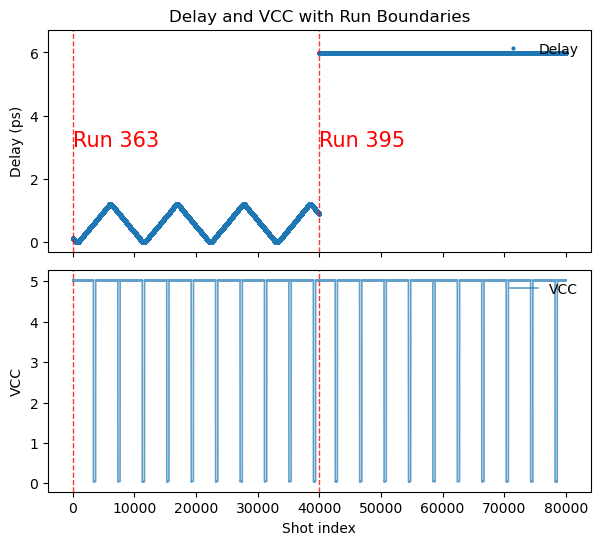

In [3]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={'hspace': 0.08}
)

# ----- Top subplot: delay -----
ax1.plot(delay_in_ps, '.', markersize=4, label='Delay')
ax1.set_ylabel('Delay (ps)')
ax1.set_title('Delay and VCC with Run Boundaries')

ymin = np.nanmin(delay_in_ps)
ymax = np.nanmax(delay_in_ps)
yrange = ymax - ymin
ax1.set_ylim(ymin - 0.05 * yrange, ymax + 0.12 * yrange)

label_y = 0.5 * (ax1.get_ylim()[0] + ax1.get_ylim()[1])
for i, run_index in enumerate(run_indices):
    ax1.axvline(run_index, color='r', linestyle='--', linewidth=1, alpha=0.8)
    ax2.axvline(run_index, color='r', linestyle='--', linewidth=1, alpha=0.8)

    ax1.text(
        run_index,
        label_y,
        f'Run {runs[i]}',
        va='center',
        ha='left',
        fontsize=15,
        color='r',
    )

ax1.legend(frameon=False, loc='upper right')

# ----- Bottom subplot: VCC -----
ax2.plot(vcc, '-', alpha=0.7, linewidth=1.2, label='VCC')
ax2.set_xlabel('Shot index')
ax2.set_ylabel('VCC')
ax2.legend(frameon=False, loc='upper right')

plt.show()

# 2D image to 1D curve pipeline

In [13]:
import numpy as np
from utils import process_run_and_save

# define target delays
target_delays = np.concatenate((np.arange(0.0, 2.0, 0.1), [2.9989]))

# example runs
runs = [363, 388]

for run in runs:
    process_run_and_save(
        run_num=run,
        target_delays=target_delays,
        exp_name="xppl1016922",
        detname="jungfrau1M_alcove",
        qmap_path="qmap.npy",
        mask_path="Mask.npy",
        outdir="Processeddata",
        nimg=1,
        image_shape=(1064, 1030),
    )

Saved VCCC outputs for run 364
Finished VCCC for run 364 in 4.51 s
Saved CC outputs for run 364
Finished CC for run 364 in 6.38 s
Saved VCCC outputs for run 389
Finished VCCC for run 389 in 2.42 s
Saved CC outputs for run 389
Finished CC for run 389 in 4.36 s


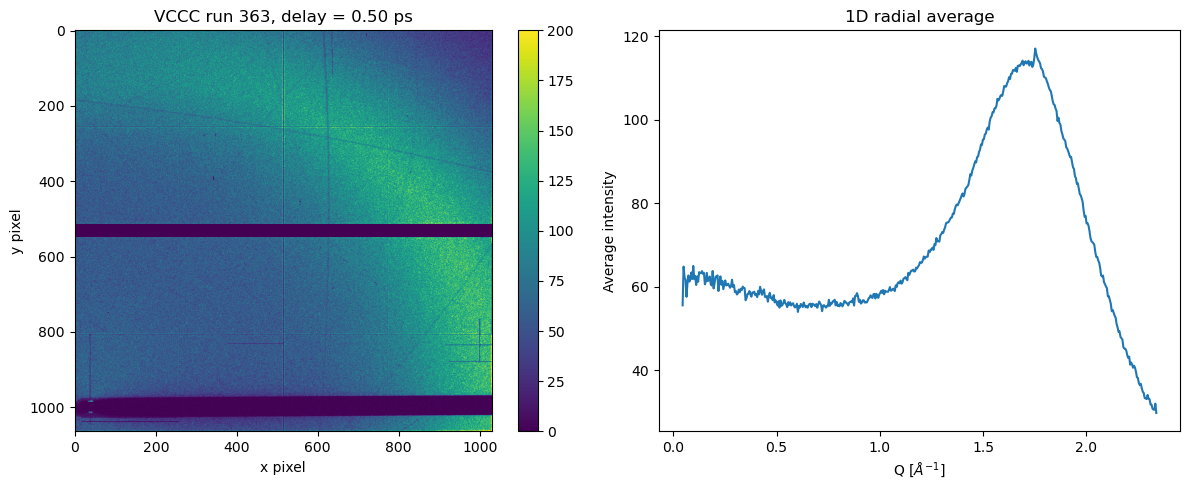

In [12]:
import numpy as np
import matplotlib.pyplot as plt

run_num = 363
delay = 0.5
prefix = "VCCC"

norm_imgs = np.load(
    f"Processeddata/{prefix}_normalized_images_by_delay_run{run_num}.npy",
    allow_pickle=True
).item()

avg_1d = np.load(
    f"Processeddata/{prefix}_average_values_run{run_num}.npy",
    allow_pickle=True
).item()

q_centers = np.load(f"Processeddata/{prefix}_q_centers_run{run_num}.npy")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im = ax1.imshow(norm_imgs[delay], aspect='auto', vmax=200)
ax1.set_title(f'{prefix} run {run_num}, delay = {delay:.2f} ps')
ax1.set_xlabel('x pixel')
ax1.set_ylabel('y pixel')
plt.colorbar(im, ax=ax1)

ax2.plot(q_centers, avg_1d[delay], '-')
ax2.set_xlabel(r'Q [$\AA^{-1}$]')
ax2.set_ylabel('Average intensity')
ax2.set_title('1D radial average')

plt.tight_layout()
plt.show()

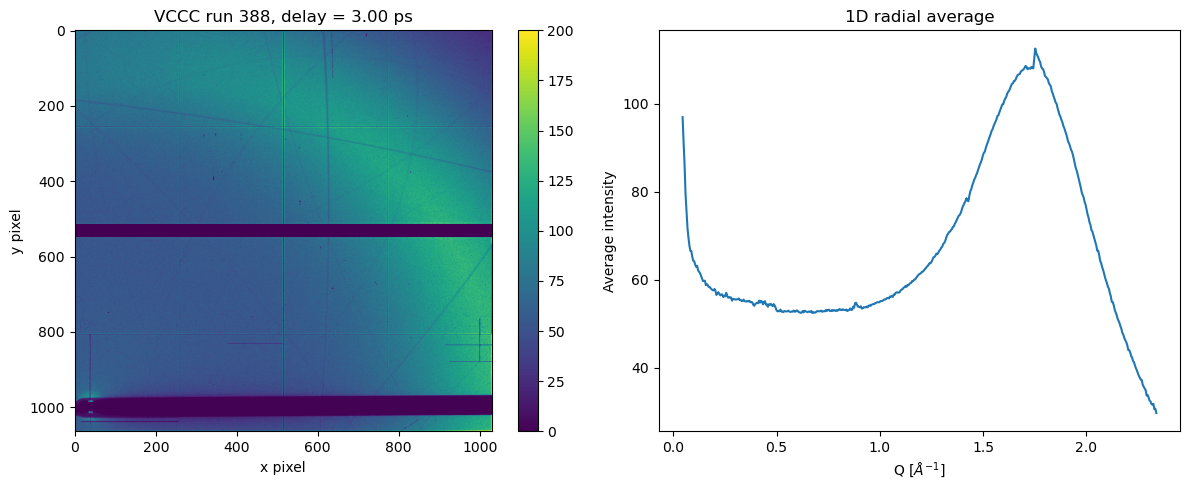

In [11]:
import numpy as np
import matplotlib.pyplot as plt

run_num = 388
delay = 2.9989
prefix = "VCCC"

norm_imgs = np.load(
    f"Processeddata/{prefix}_normalized_images_by_delay_run{run_num}.npy",
    allow_pickle=True
).item()

avg_1d = np.load(
    f"Processeddata/{prefix}_average_values_run{run_num}.npy",
    allow_pickle=True
).item()

q_centers = np.load(f"Processeddata/{prefix}_q_centers_run{run_num}.npy")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im = ax1.imshow(norm_imgs[delay], aspect='auto',vmax=200)
ax1.set_title(f'{prefix} run {run_num}, delay = {delay:.2f} ps')
ax1.set_xlabel('x pixel')
ax1.set_ylabel('y pixel')
plt.colorbar(im, ax=ax1)

ax2.plot(q_centers, avg_1d[delay], '-')
ax2.set_xlabel(r'Q [$\AA^{-1}$]')
ax2.set_ylabel('Average intensity')
ax2.set_title('1D radial average')

plt.tight_layout()
plt.show()